<a href="https://colab.research.google.com/github/catdavis25/HeartDiseaseClassifier/blob/main/MLFinalCleanup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/heart_data.csv") # removed / for loading dataset (stored in Files)

In [ ]:
# Display Dataset Head
df.head()

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Display Dataset Head
df.tail()

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [ ]:
# Count Rows and Columns
df.shape

(70000, 14)

In [ ]:
# Summarize Feature Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        70000 non-null  int64  
 1   id           70000 non-null  int64  
 2   age          70000 non-null  int64  
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  int64  
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB


In [ ]:
# Summarize Full Raw Dataset
df.describe()

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,20207.403759,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,34999.500000,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,52499.250000,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,69999.000000,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Count Missing Continuous Data
df.isnull().sum()

,0
index,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0


In [ ]:
# Count Missing Categorical Data
df.isna().sum()

,0
index,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0


In [ ]:
sum(df.duplicated())

0

In [ ]:
# Drop Unnecessary Data
df = df.drop('index', axis=1)
df = df.drop('id', axis=1)

**Eliminate Outliers**

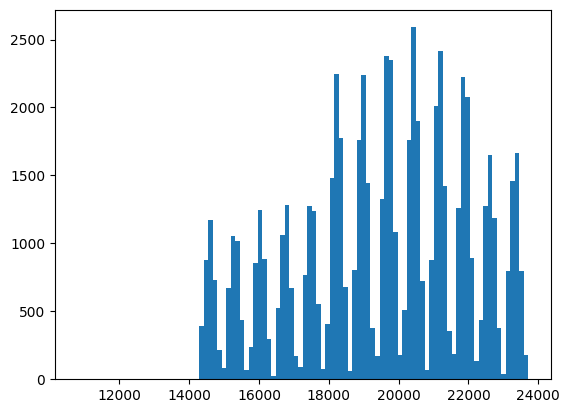

In [ ]:
plt.hist(df['age'], bins=100)
plt.show()

In [ ]:
floor = 0.25
ceiling = 0.75
Q1 = df['age'].quantile(0.20)
Q3 = df['age'].quantile(1)
# Q1 = df['age'].quantile(floor)
# Q3 = df['age'].quantile(ceiling)
# IQR = Q3 - Q1
# threshold = 1.5
# outliers = df[(df['age'] < Q1 - threshold * IQR) | (df['age'] > Q3 + threshold * IQR)]
# df = df.drop(outliers.index)

df.drop(df[df.age < 14000].index, inplace=True)
df.drop(df[df.age > 24000].index, inplace=True)

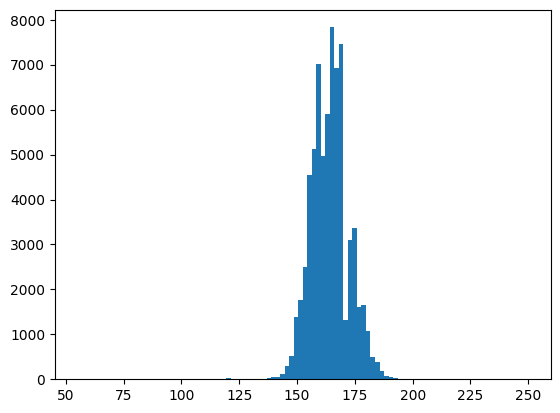

In [ ]:
plt.hist(df['height'], bins=100)
plt.show()

In [ ]:
Q1 = df['height'].quantile(0.1)
Q3 = df['height'].quantile(0.85)
# Q1 = df['height'].quantile(floor)
# Q3 = df['height'].quantile(ceiling)
# IQR = Q3 - Q1
# threshold = 1.5
# outliers = df[(df['height'] < Q1 - threshold * IQR) | (df['height'] > Q3 + threshold * IQR)]
# df = df.drop(outliers.index)

df.drop(df[df.height < 140].index, inplace=True)
df.drop(df[df.height > 185].index, inplace=True)

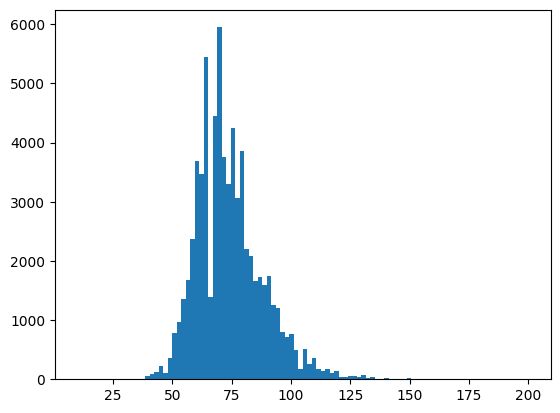

In [ ]:
plt.hist(df['weight'], bins=100)
plt.show()

In [ ]:
Q1 = df['weight'].quantile(0.20)
Q3 = df['weight'].quantile(0.9)
# Q1 = df['weight'].quantile(floor)
# Q3 = df['weight'].quantile(ceiling)
# IQR = Q3 - Q1
# threshold = 1.5
# outliers = df[(df['weight'] < Q1 - threshold * IQR) | (df['weight'] > Q3 + threshold * IQR)]
# df = df.drop(outliers.index)

df.drop(df[df.weight < 45].index, inplace=True) # 40, 45
df.drop(df[df.weight > 125].index, inplace=True) # 125, 125

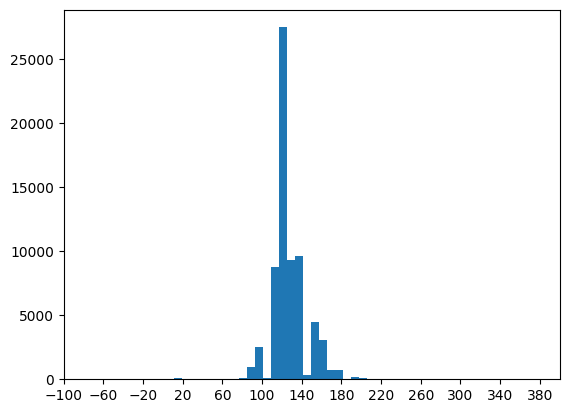

In [ ]:
plt.hist(df['ap_hi'], bins=2000)
plt.xlim(-100, 400)
plt.xticks(ticks=range(-100, 400, 40))
plt.show()

In [ ]:
Q1 = df['ap_hi'].quantile(0.2)
Q3 = df['ap_hi'].quantile(0.80)
# Q1 = df['ap_hi'].quantile(floor)
# Q3 = df['ap_hi'].quantile(ceiling)
# IQR = Q3 - Q1
# threshold = 1.5
# outliers = df[(df['ap_hi'] < Q1 - threshold * IQR) | (df['ap_hi'] > Q3 + threshold * IQR)]
# df = df.drop(outliers.index)

df.drop(df[df.ap_hi < 80].index, inplace=True) # 60, 70
df.drop(df[df.ap_hi > 200].index, inplace=True) # 180, 180

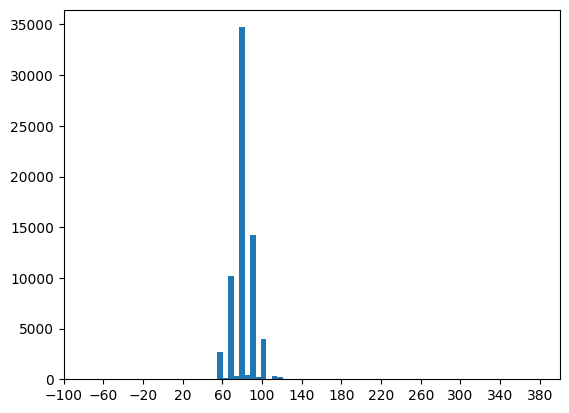

In [ ]:
plt.hist(df['ap_lo'], bins=2000)
plt.xlim(-100, 400)
plt.xticks(ticks=range(-100, 400, 40))
plt.show()

In [ ]:
Q1 = df['ap_lo'].quantile(0.6)
Q3 = df['ap_lo'].quantile(0.8)
# Q1 = df['ap_lo'].quantile(floor)
# Q3 = df['ap_lo'].quantile(ceiling)
# IQR = Q3 - Q1
# threshold = 1.5
# outliers = df[(df['ap_lo'] < Q1 - threshold * IQR) | (df['ap_lo'] > Q3 + threshold * IQR)]
# df = df.drop(outliers.index)

df.drop(df[df.ap_lo < 50].index, inplace=True) # 45, 60
df.drop(df[df.ap_lo > 140].index, inplace=True) # 115, 115

In [ ]:
df.shape

(67555, 12)

In [ ]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000
mean,19470.421020,1.347051,164.361084,73.872303,126.553223,81.323929,1.363896,1.224721,0.087425,0.053083,0.803523,0.494634
std,2465.461108,0.476036,7.577376,13.402009,16.462187,9.405815,0.678522,0.570665,0.282459,0.224200,0.397336,0.499975
min,14275.000000,1.000000,140.000000,45.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17666.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19704.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21328.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,185.000000,125.000000,200.000000,140.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isna().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


In [ ]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


In [ ]:
# Min-Max Normalize Continous Data Between 0 and 1
scaler = MinMaxScaler()

df["age"] = scaler.fit_transform(df[["age"]])
df["gender"] = scaler.fit_transform(df[["gender"]]) # For some reason raw value is either 1 or 2 -> So now 0 or 1
df["height"] = scaler.fit_transform(df[["height"]])
df["weight"] = scaler.fit_transform(df[["weight"]])
df["ap_hi"] = scaler.fit_transform(df[["ap_hi"]])
df["ap_lo"] = scaler.fit_transform(df[["ap_lo"]])
df["cholesterol"] = scaler.fit_transform(df[["cholesterol"]])
df["gluc"] = scaler.fit_transform(df[["gluc"]])



df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,6.755500e+04,67555.000000,6.755500e+04,6.755500e+04,6.755500e+04,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000,67555.000000
mean,-4.549030e-17,0.347051,4.592154e-16,-2.385480e-16,3.807512e-17,0.348044,0.181948,0.112360,0.087425,0.053083,0.803523,0.494634
std,1.000007e+00,0.476036,1.000007e+00,1.000007e+00,1.000007e+00,0.104509,0.339261,0.285332,0.282459,0.224200,0.397336,0.499975
min,-2.107297e+00,0.000000,-3.215000e+00,-2.154343e+00,-2.827909e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.318852e-01,0.000000,-7.075171e-01,-6.620179e-01,-3.980803e-01,0.333333,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,9.474119e-02,0.000000,8.431958e-02,-1.397042e-01,-3.980803e-01,0.333333,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,7.534464e-01,1.000000,7.441835e-01,6.064581e-01,8.168341e-01,0.444444,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.720818e+00,1.000000,2.723775e+00,3.814956e+00,4.461577e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Fix Data Types
feature_conversions = {'gender': bool, 'smoke': bool, 'alco': bool, 'active': bool, 'cardio': bool}
df = df.astype(feature_conversions)

print(df.dtypes)

age            float64
gender            bool
height         float64
weight         float64
ap_hi          float64
ap_lo          float64
cholesterol    float64
gluc           float64
smoke             bool
alco              bool
active            bool
cardio            bool
dtype: object


In [ ]:
# Examine New Data Format
df.head(15)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,-0.437009,True,0.480238,-0.885867,-1.005537,0.333333,0.0,0.0,False,False,True,False
1,0.307279,False,-1.103435,0.830307,0.816834,0.444444,1.0,0.0,False,False,True,True
2,-0.248808,False,0.084320,-0.736634,0.209377,0.222222,1.0,0.0,False,False,False,True
3,-0.749326,True,0.612211,0.606458,1.424291,0.555556,0.0,0.0,False,False,True,True
4,-0.809762,False,-1.103435,-1.333564,-1.612995,0.111111,0.0,0.0,False,False,False,False
5,0.991132,False,-1.763299,-0.512785,-0.398080,0.333333,0.5,0.5,False,False,False,False
6,1.071848,False,-0.971463,1.427237,0.209377,0.333333,1.0,0.0,False,False,True,False
7,1.262888,True,1.799966,1.576469,0.209377,0.444444,1.0,1.0,False,False,True,True
8,-0.731074,False,-0.839490,-0.214320,-1.005537,0.222222,0.0,0.0,False,False,True,False
9,0.147470,False,-0.047653,-0.438169,-1.005537,0.111111,0.0,0.0,False,False,False,False


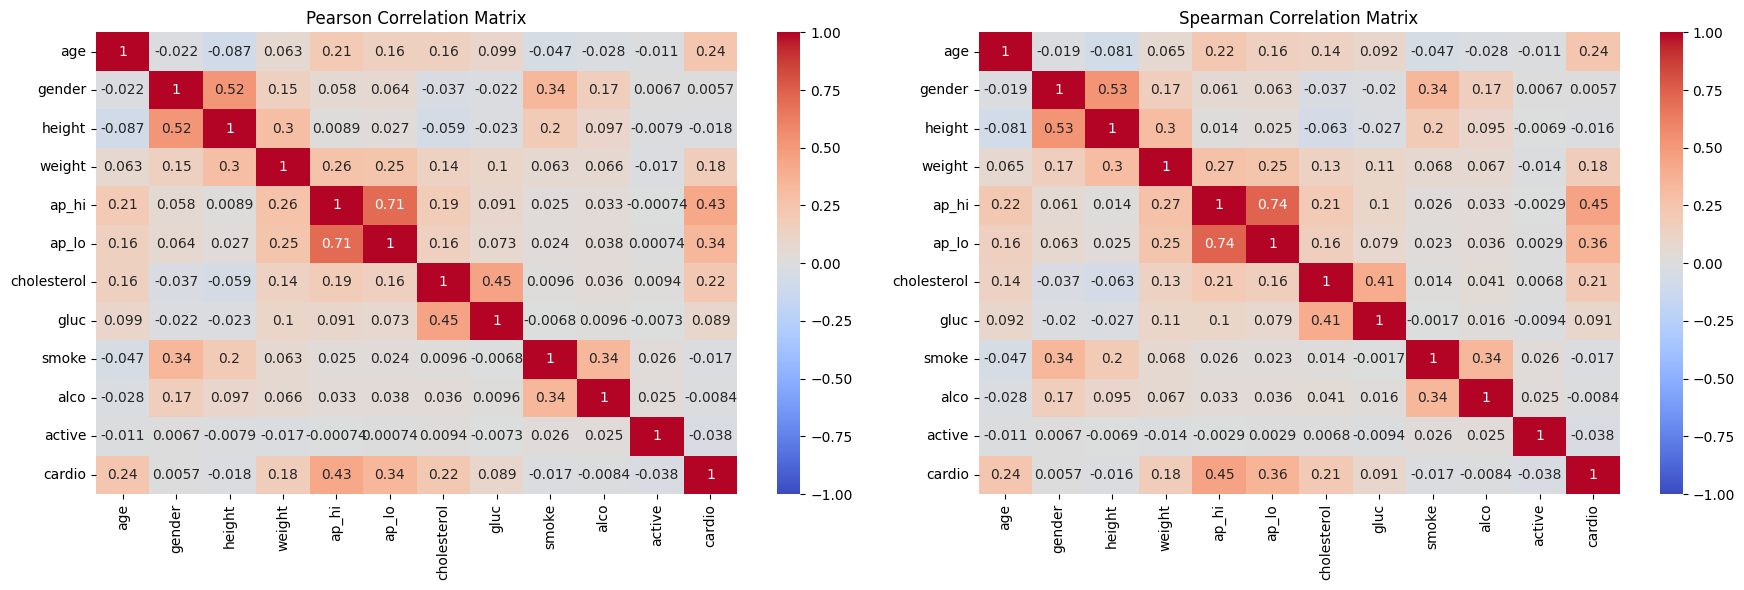

In [ ]:
# Dimensionality Reduction

# Correlation matrices
pearson_corr = df.corr(method='pearson')
# Set up the plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Pearson correlation matric - linear relationships
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax1)
ax1.set_title("Pearson Correlation Matrix")
# Spearman’s correlation matrix - monotonic relationships
spearman_corr = df.corr(method='spearman')

sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax2)
ax2.set_title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

# Linear: (gender. height), (cholesterol, glucose)
# Monotonic: (ap_hi, ap_lo), (ap_hi, cardio), (ap_lo, cardio)

Explained variance by each component: [0.29147424 0.18260825]


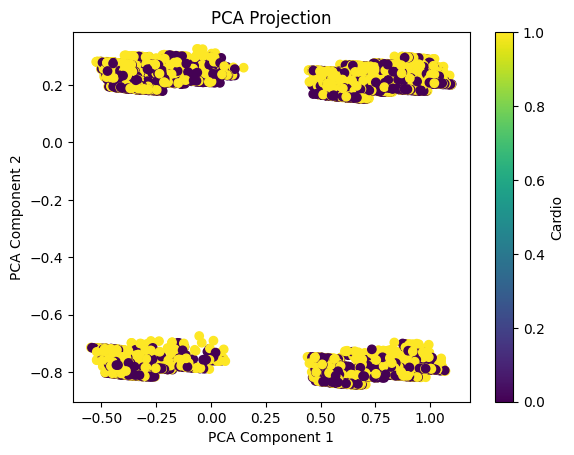

In [ ]:
# Principal Component Analysis (PCA) or Linear Discriminant Analysis (LDA)
# PCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["cardio"])  # Features
y = df["cardio"]  # Target

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Explained variance ratio
print(f'Explained variance by each component: {pca.explained_variance_ratio_}')

# Visualize PCA results
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cardio')
plt.title('PCA Projection')
plt.show()

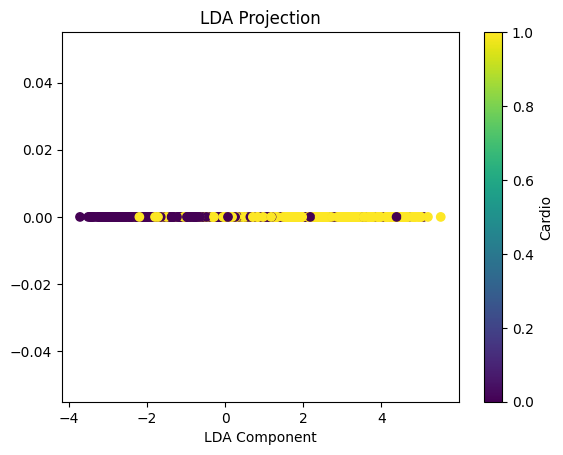

In [ ]:
# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

# Visualize LDA result
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis')
plt.xlabel('LDA Component')
plt.colorbar(label='Cardio')
plt.title('LDA Projection')
plt.show()

In [ ]:
# Save Data
df.to_csv("cleaned_heart_data.csv", encoding='utf-8', index=False)